<a href="https://colab.research.google.com/github/tinawanggg/Wang_DSPN_S26/blob/master/book/exercises/16_selecting-the-best-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [2]:
# WRITE YOUR CODE HERE
set.seed(15)

X <- rnorm(100)
eps <- rnorm(100)

b0 <- 3
b1 <- 2
b2 <- -1
b3 <- 0.5

Y <- b0 + b1*X + b2*X^2 + b3*X^3 + eps

b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [6]:
# WRITE YOUR CODE HERE
install.packages("leaps")
library(leaps)

dat <- data.frame(Y, X, X2 = X^2, X3 = X^3, X4 = X^4, X5 = X^5,
                  X6 = X^6, X7 = X^7, X8 = X^8, X9 = X^9, X10 = X^10)

regfit_full <- regsubsets(Y ~ ., data = dat, nvmax = 10)
reg_summary <- summary(regfit_full)
print(reg_summary)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Subset selection object
Call: regsubsets.formula(Y ~ ., data = dat, nvmax = 10)
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: exhaustive
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  "*" " " " " "*" " " " " " " " " " " " "
3  ( 1 )  "*" " " "*" "*" " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" " " " " "*" " " " " " " " "
5  ( 1 )  "*" "*" "*" " " "*" "*" " " " " " " " "
6  ( 1 )  "*" " " "*" " " "*" "*" " " "*" " " "*"
7  ( 1 )  "*" "*" "*" "*" " " "*" " " "*" " " "*"
8  ( 1 )  "*" "*" "*" "*" "*" "*" " " "*" " " "*"
9  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" "*" "*" "*" "*" "*"


In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Based on each criterion, identify the best model size. Report the coefficients of the best model.

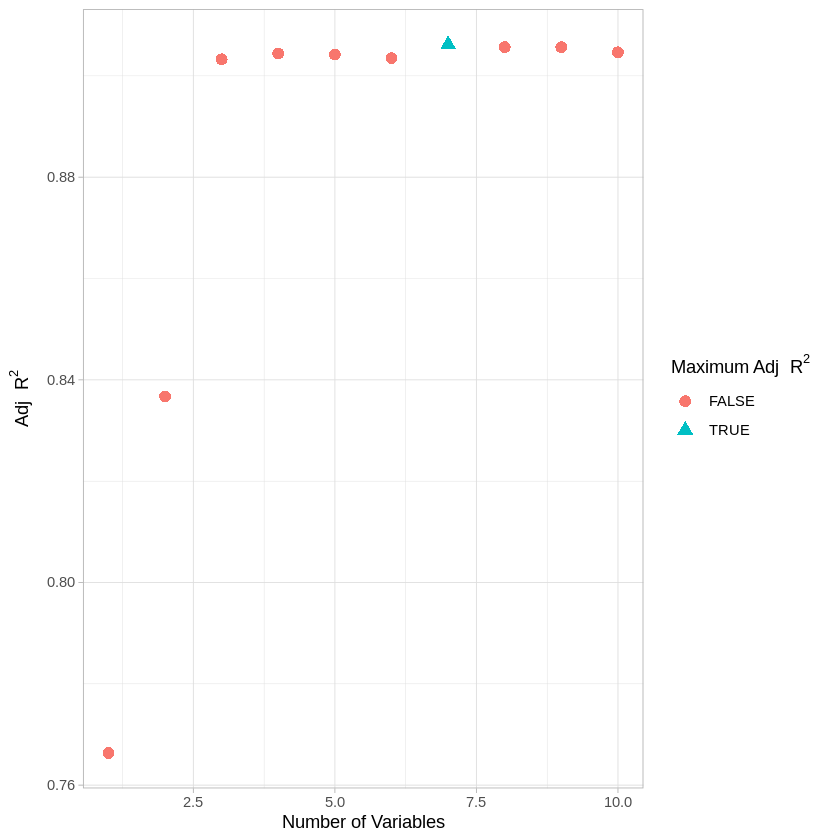

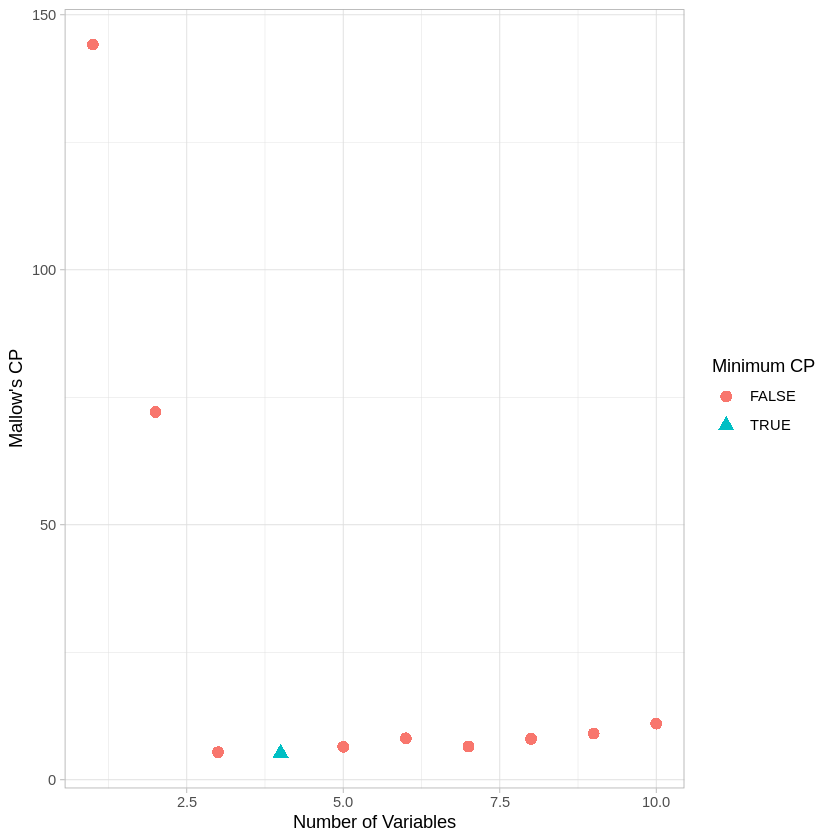

Best model size by Cp: 4 
Best model size by BIC: 3 
Best model size by Adjusted R^2: 7 
(Intercept)           X          X2          X3          X6 
 2.56961161  2.03196689 -0.49913369  0.49080549 -0.01730072 
(Intercept)           X          X3          X4 
  2.3808542   2.0090539   0.4985483  -0.1857347 
(Intercept)           X          X2          X3          X4          X6 
 2.78997778  2.03229059 -2.68341292  0.49962606  3.40354276 -1.83974566 
         X8         X10 
 0.38471197 -0.02758752 


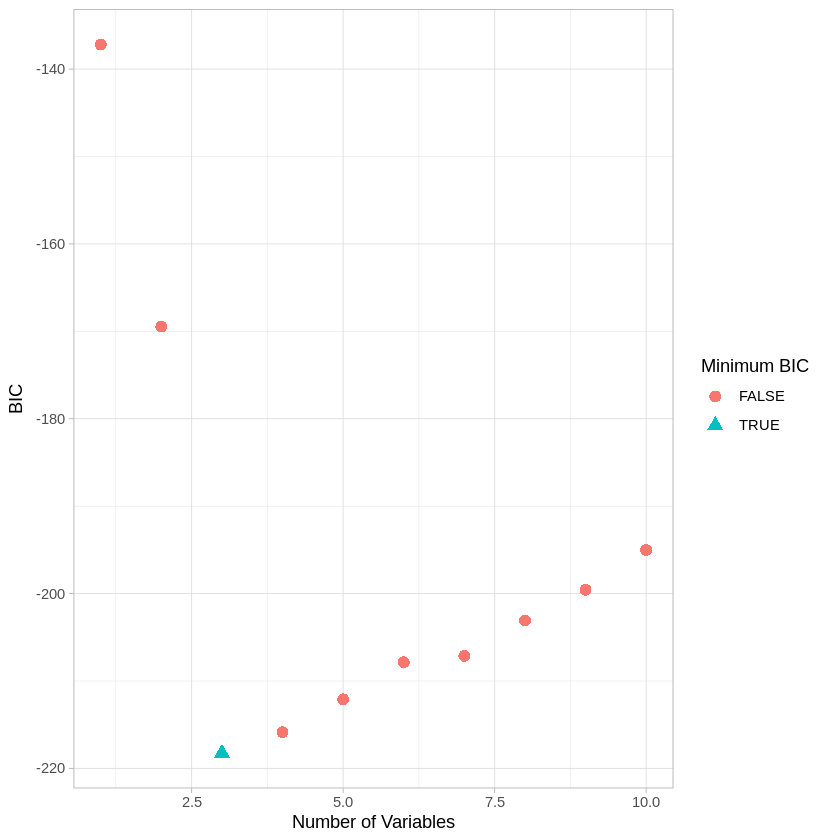

In [13]:
# WRITE YOUR CODE HERE
library(ggplot2)

numvar <- 1:length(reg_summary$rss)
allfalse <- rep(FALSE, length(reg_summary$rss))

# Adjusted R^2
adjr2.df <- data.frame(numvar = numvar, adjr2 = reg_summary$adjr2, maxadjr2 = allfalse)
adjr2.df$maxadjr2[which.max(reg_summary$adjr2)] <- TRUE
ggplot(adjr2.df, aes(x = numvar, y = adjr2, shape = maxadjr2, col = maxadjr2)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = 'Adj'~R^2, color = 'Maximum Adj'~R^2, shape = 'Maximum Adj'~R^2)

# Mallow's Cp
cp.df <- data.frame(numvar = numvar, cp = reg_summary$cp, mincp = allfalse)
cp.df$mincp[which.min(reg_summary$cp)] <- TRUE
ggplot(cp.df, aes(x = numvar, y = cp, shape = mincp, col = mincp)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = "Mallow's CP", color = "Minimum CP", shape = "Minimum CP")

# BIC
bic.df <- data.frame(numvar = numvar, bic = reg_summary$bic, minbic = allfalse)
bic.df$minbic[which.min(reg_summary$bic)] <- TRUE
ggplot(bic.df, aes(x = numvar, y = bic, shape = minbic, col = minbic)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = "BIC", color = "Minimum BIC", shape = "Minimum BIC")

# Best model sizes
cat("Best model size by Cp:", which.min(reg_summary$cp), "\n")
cat("Best model size by BIC:", which.min(reg_summary$bic), "\n")
cat("Best model size by Adjusted R^2:", which.max(reg_summary$adjr2), "\n")

# Coefficients of best model per criterion
print(coef(regfit_full, which.min(reg_summary$cp)))
print(coef(regfit_full, which.min(reg_summary$bic)))
print(coef(regfit_full, which.max(reg_summary$adjr2)))

> *BIC selected 3 predictors (X, X³, X⁴), Cp selected 4 predictors (X, X², X³, X⁶), and Adjusted R² selected 7 predictors (X, X², X³, X⁴, X⁶, X⁸, X¹⁰). Since the true model contains X, X², and X³, Cp performed the best as it correctly recovered all three true predictors with relatively accurate coefficients (b₁ ≈ 2.03, b₂ ≈ −0.50, b₃ ≈ 0.49) with only one extra term (X⁶ ≈ −0.02).*
>

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to identify the best model under each criterion. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

Subset selection object
Call: regsubsets.formula(Y ~ ., data = dat, nvmax = 10, method = "forward")
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: forward
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  "*" " " " " "*" " " " " " " " " " " " "
3  ( 1 )  "*" " " "*" "*" " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" "*" " " " " " " " " " " " "
5  ( 1 )  "*" "*" "*" "*" " " " " " " " " "*" " "
6  ( 1 )  "*" "*" "*" "*" " " "*" " " " " "*" " "
7  ( 1 )  "*" "*" "*" "*" "*" "*" " " " " "*" " "
8  ( 1 )  "*" "*" "*" "*" "*" "*" "*" " " "*" " "
9  ( 1 )  "*" "*" "*" "*" "*" "*" "*" "*" "*" " "
10  ( 1 ) "*" "*" "*" "*" "*" "*" 

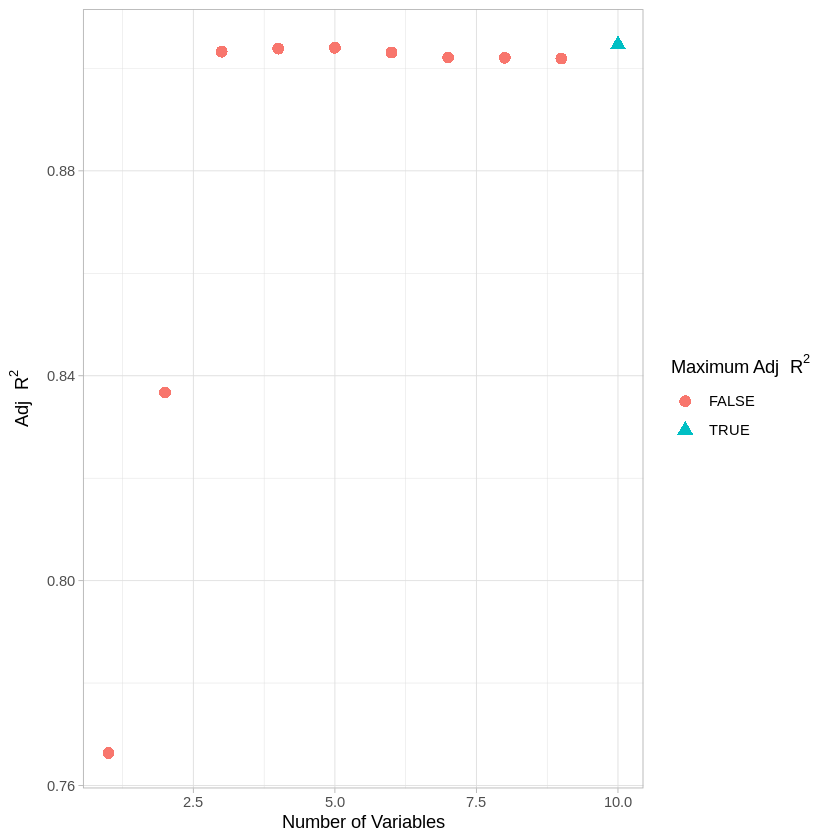

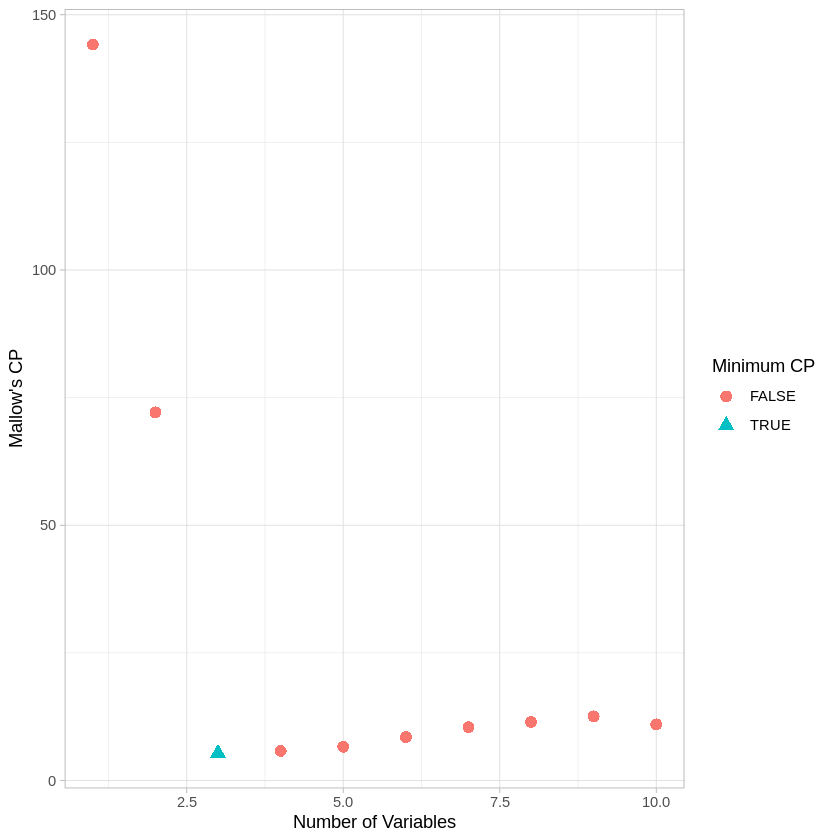

Best model size by Cp: 3 
Best model size by BIC: 3 
Best model size by Adjusted R^2: 10 
(Intercept)           X          X3          X4 
  2.3808542   2.0090539   0.4985483  -0.1857347 
(Intercept)           X          X3          X4 
  2.3808542   2.0090539   0.4985483  -0.1857347 
(Intercept)           X          X2          X3          X4          X5 
 2.78609509  1.79059644 -2.84662431  0.40679491  3.94561346  0.43864566 
         X6          X7          X8          X9         X10 
-2.29110020 -0.17943734  0.51414033  0.01839975 -0.03902664 


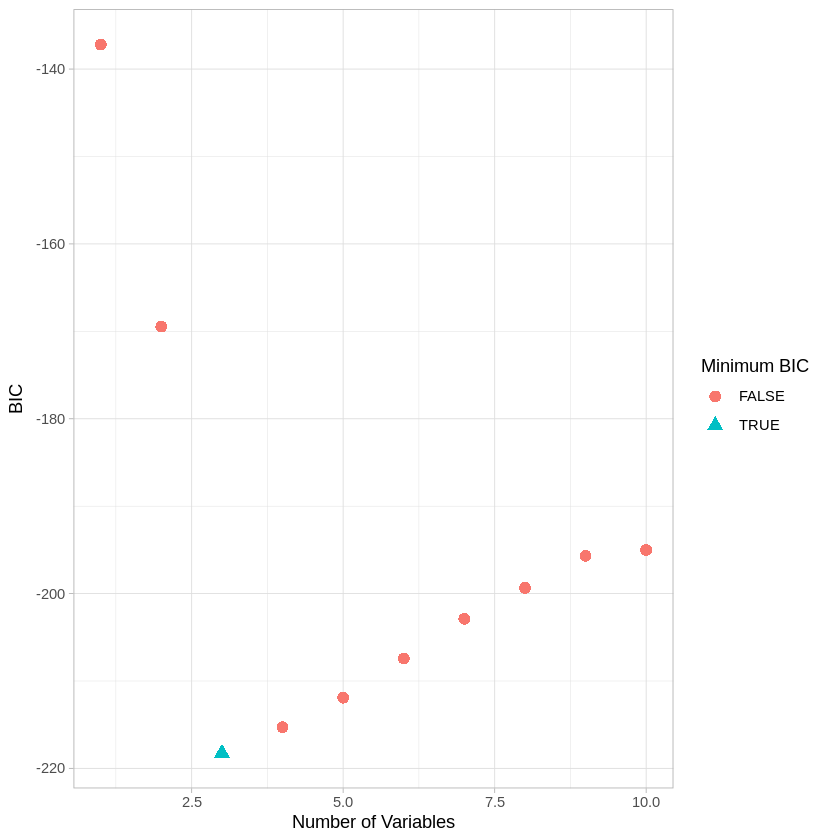

In [15]:
# WRITE YOUR CODE HERE
# Forward stepwise selection
regfit_fwd <- regsubsets(Y ~ ., data = dat, nvmax = 10, method = "forward")
fwd_summary <- summary(regfit_fwd)
print(fwd_summary)

numvar <- 1:length(fwd_summary$rss)
allfalse <- rep(FALSE, length(fwd_summary$rss))

# Adjusted R^2
adjr2.df <- data.frame(numvar = numvar, adjr2 = fwd_summary$adjr2, maxadjr2 = allfalse)
adjr2.df$maxadjr2[which.max(fwd_summary$adjr2)] <- TRUE
ggplot(adjr2.df, aes(x = numvar, y = adjr2, shape = maxadjr2, col = maxadjr2)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = 'Adj'~R^2, color = 'Maximum Adj'~R^2, shape = 'Maximum Adj'~R^2)

# Mallow's Cp
cp.df <- data.frame(numvar = numvar, cp = fwd_summary$cp, mincp = allfalse)
cp.df$mincp[which.min(fwd_summary$cp)] <- TRUE
ggplot(cp.df, aes(x = numvar, y = cp, shape = mincp, col = mincp)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = "Mallow's CP", color = "Minimum CP", shape = "Minimum CP")

# BIC
bic.df <- data.frame(numvar = numvar, bic = fwd_summary$bic, minbic = allfalse)
bic.df$minbic[which.min(fwd_summary$bic)] <- TRUE
ggplot(bic.df, aes(x = numvar, y = bic, shape = minbic, col = minbic)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = "BIC", color = "Minimum BIC", shape = "Minimum BIC")

# Best model sizes
cat("Best model size by Cp:", which.min(fwd_summary$cp), "\n")
cat("Best model size by BIC:", which.min(fwd_summary$bic), "\n")
cat("Best model size by Adjusted R^2:", which.max(fwd_summary$adjr2), "\n")

# Coefficients
print(coef(regfit_fwd, which.min(fwd_summary$cp)))
print(coef(regfit_fwd, which.min(fwd_summary$bic)))
print(coef(regfit_fwd, which.max(fwd_summary$adjr2)))

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

b) Backwards stepwise selection:

Subset selection object
Call: regsubsets.formula(Y ~ ., data = dat, nvmax = 10, method = "backward")
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: backward
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  "*" " " " " " " " " "*" " " " " " " " "
3  ( 1 )  "*" " " " " " " "*" "*" " " " " " " " "
4  ( 1 )  "*" "*" " " " " "*" "*" " " " " " " " "
5  ( 1 )  "*" "*" " " " " "*" "*" "*" " " " " " "
6  ( 1 )  "*" "*" " " " " "*" "*" "*" "*" " " " "
7  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" " " " "
8  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" " " "*"
9  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" "*

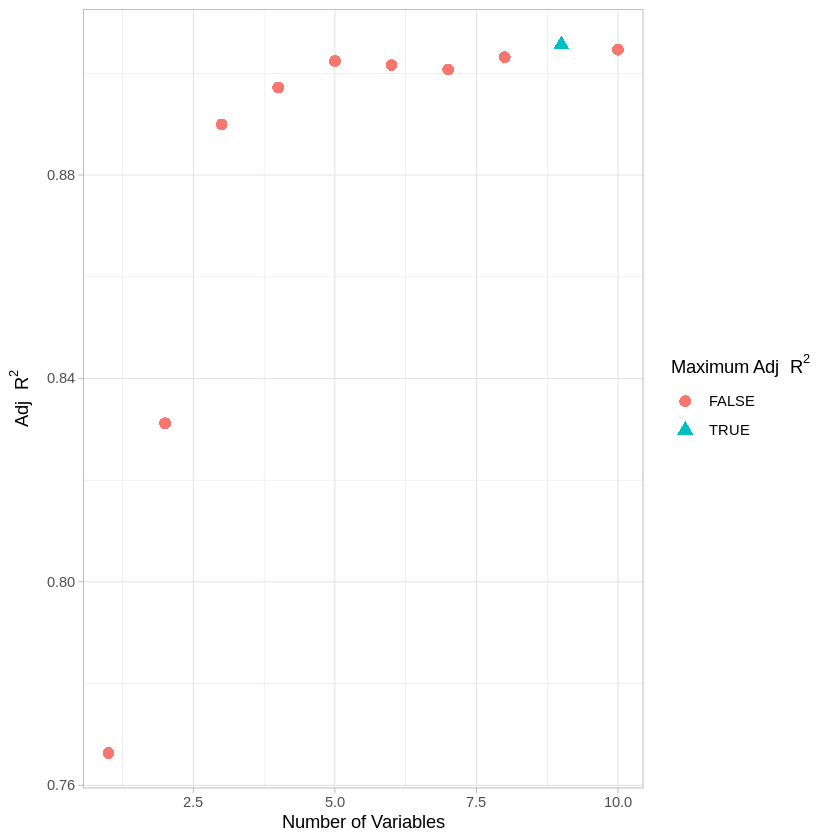

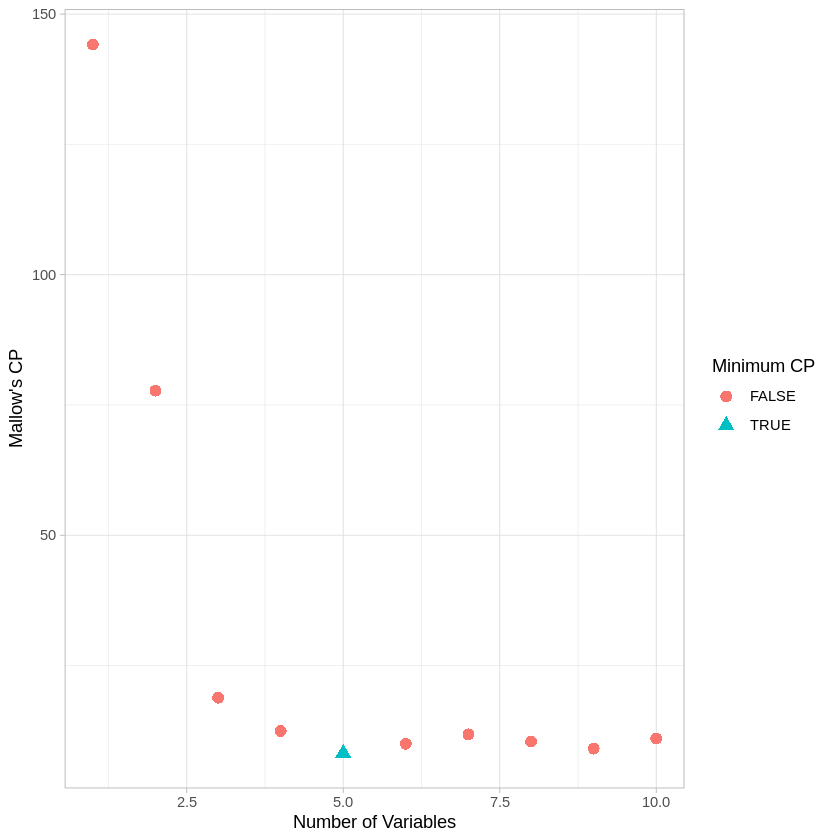

Best model size by Cp: 5 
Best model size by BIC: 5 
Best model size by Adjusted R^2: 9 
(Intercept)           X          X2          X5          X6          X7 
 2.59814290  2.28224283 -0.54726429  0.22256438 -0.01604063 -0.02528877 
(Intercept)           X          X2          X5          X6          X7 
 2.59814290  2.28224283 -0.54726429  0.22256438 -0.01604063 -0.02528877 
(Intercept)           X          X2          X4          X5          X6 
 2.79373173  1.92635318 -2.91122489  4.10512634  0.75564468 -2.41441373 
         X7          X8          X9         X10 
-0.26614872  0.54831317  0.02584671 -0.04199418 


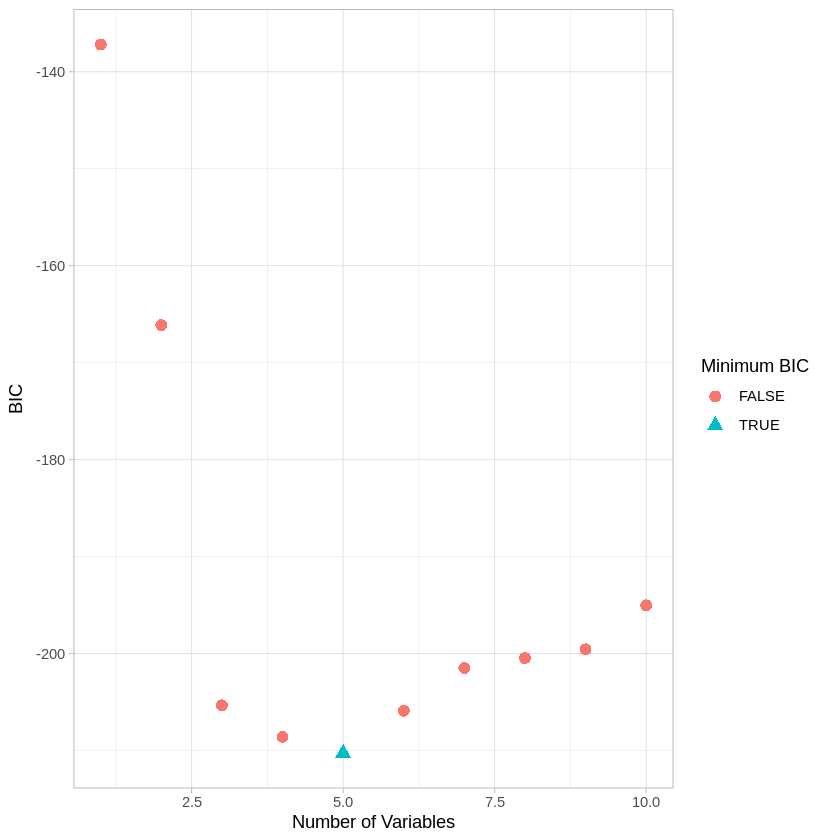

In [16]:
# WRITE YOUR CODE HERE
# Backward stepwise selection
regfit_bwd <- regsubsets(Y ~ ., data = dat, nvmax = 10, method = "backward")
bwd_summary <- summary(regfit_bwd)
print(bwd_summary)

numvar <- 1:length(bwd_summary$rss)
allfalse <- rep(FALSE, length(bwd_summary$rss))

# Adjusted R^2
adjr2.df <- data.frame(numvar = numvar, adjr2 = bwd_summary$adjr2, maxadjr2 = allfalse)
adjr2.df$maxadjr2[which.max(bwd_summary$adjr2)] <- TRUE
ggplot(adjr2.df, aes(x = numvar, y = adjr2, shape = maxadjr2, col = maxadjr2)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = 'Adj'~R^2, color = 'Maximum Adj'~R^2, shape = 'Maximum Adj'~R^2)

# Mallow's Cp
cp.df <- data.frame(numvar = numvar, cp = bwd_summary$cp, mincp = allfalse)
cp.df$mincp[which.min(bwd_summary$cp)] <- TRUE
ggplot(cp.df, aes(x = numvar, y = cp, shape = mincp, col = mincp)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = "Mallow's CP", color = "Minimum CP", shape = "Minimum CP")

# BIC
bic.df <- data.frame(numvar = numvar, bic = bwd_summary$bic, minbic = allfalse)
bic.df$minbic[which.min(bwd_summary$bic)] <- TRUE
ggplot(bic.df, aes(x = numvar, y = bic, shape = minbic, col = minbic)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = "BIC", color = "Minimum BIC", shape = "Minimum BIC")

# Best model sizes
cat("Best model size by Cp:", which.min(bwd_summary$cp), "\n")
cat("Best model size by BIC:", which.min(bwd_summary$bic), "\n")
cat("Best model size by Adjusted R^2:", which.max(bwd_summary$adjr2), "\n")

# Coefficients
print(coef(regfit_bwd, which.min(bwd_summary$cp)))
print(coef(regfit_bwd, which.min(bwd_summary$bic)))
print(coef(regfit_bwd, which.max(bwd_summary$adjr2)))

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Compare your results from parts a and b with those of question 1. Did the two methods select similar model sizes and predictors? If not, how did they differ?

> *Across all three methods, BIC consistently favored smaller models (3–5 predictors) while Adjusted R² consistently slected larger models (7–10 predictors) with inconsistent coefficients. Best subset and forward stepwise agreed most closely, as both selected 3 predictors under BIC and recovered X and X³ with accurate coefficients (b₁ ≈ 2.01, b₃ ≈ 0.50), although neither recovered the true X² term. Backward stepwise differed noticeably, selecting 5 predictors under both Cp and BIC with a different set of terms (X, X², X⁵, X⁶, X⁷) that includes X² but adds several extra terms. Overall, no method perfectly recovered the true model (X, X², X³), although best subset with Cp came the closest.*
>

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [23]:
# WRITE YOUR CODE HERE
set.seed(15)

n <- 1000
p <- 20

X <- matrix(rnorm(n * p), nrow = n, ncol = p)

beta <- c(3, -2, 1.5, 0, 0, 2, 0, -1, 0, 0,
          0.5, 0, 0, -1.5, 0, 0, 1, 0, 0, 2)

eps <- rnorm(n)
Y <- X %*% beta + eps

dat2 <- data.frame(Y, X)
colnames(dat2) <- c("Y", paste0("X", 1:p))

train_idx <- sample(1:n, 100)
train <- dat2[train_idx, ]
test  <- dat2[-train_idx, ]

b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

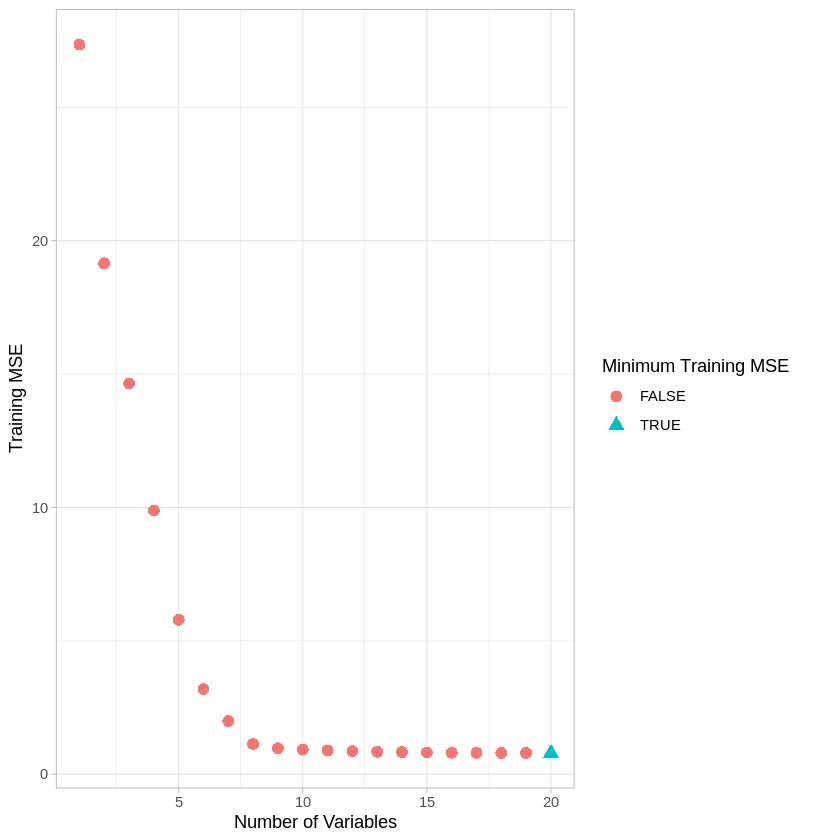

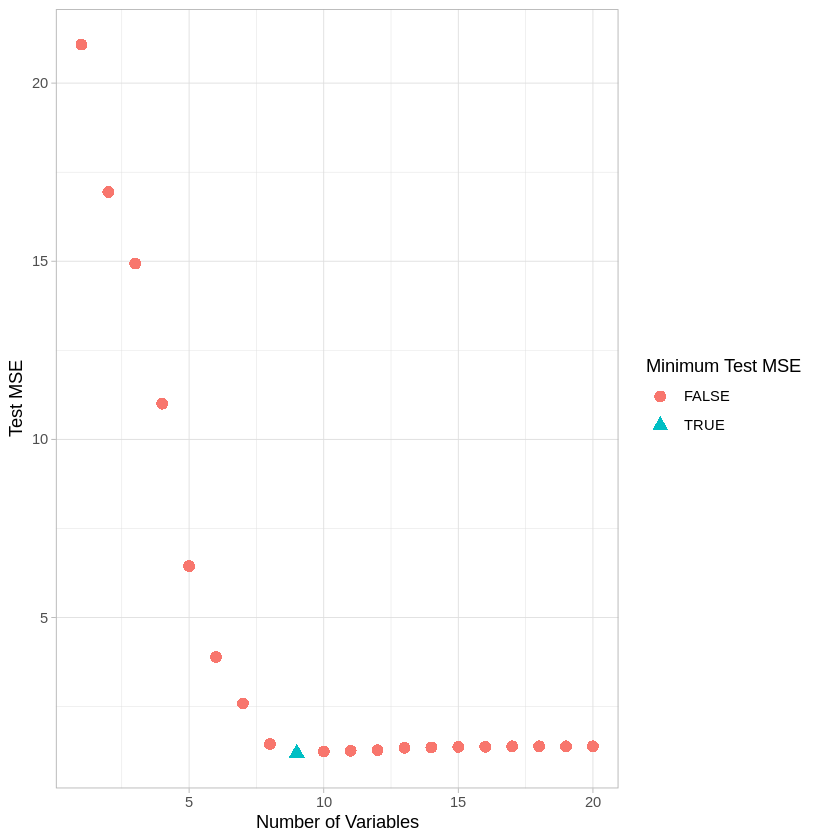

In [27]:
# WRITE YOUR CODE HERE
regfit_train <- regsubsets(Y ~ ., data = train, nvmax = 20)
train_summary <- summary(regfit_train)

train_mse <- train_summary$rss / 100

test_mse <- rep(NA, 20)
for (i in 1:20) {
  coefi    <- coef(regfit_train, id = i)
  test_mat <- model.matrix(Y ~ ., data = test)
  pred     <- test_mat[, names(coefi)] %*% coefi
  test_mse[i] <- mean((test$Y - pred)^2)
}

numvar   <- 1:20
allfalse <- rep(FALSE, 20)

# Training MSE plot
trainmse.df <- data.frame(numvar = numvar, trainmse = train_mse, mintrainmse = allfalse)
trainmse.df$mintrainmse[which.min(train_mse)] <- TRUE
ggplot(trainmse.df, aes(x = numvar, y = trainmse, shape = mintrainmse, col = mintrainmse)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = "Training MSE",
       color = "Minimum Training MSE", shape = "Minimum Training MSE")

# Test MSE plot
testmse.df <- data.frame(numvar = numvar, testmse = test_mse, mintestmse = allfalse)
testmse.df$mintestmse[which.min(test_mse)] <- TRUE
ggplot(testmse.df, aes(x = numvar, y = testmse, shape = mintestmse, col = mintestmse)) +
  geom_point(size = 3) + theme_light() +
  labs(x = "Number of Variables", y = "Test MSE",
       color = "Minimum Test MSE", shape = "Minimum Test MSE")

c) Identify the best model according to the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [29]:
# WRITE YOUR CODE HERE
best_size <- which.min(test_mse)
cat("Best model size by test MSE:", best_size, "\n")

cat("\nCoefficients of best model:\n")
print(coef(regfit_train, best_size))

Best model size by test MSE: 9 

Coefficients of best model:
(Intercept)          X1          X2          X3          X6          X8 
-0.01167972  2.96545105 -1.97120485  1.68054533  2.05671769 -1.17882782 
        X11         X14         X17         X20 
 0.50114706 -1.24451115  1.00588859  2.05732987 


> *The best model identified 9 predictors (X1, X2, X3, X6, X8, X11, X14, X17, X20), which perfectly matches the true non-zero predictors used to simulate the data. The estimated coefficients were also very close to the true values (β1=3, β2=−2, β3=1.5, β6=2, β8=−1, β11=0.5, β14=−1.5, β17=1, β20=2), with the largest deviation being X8 (estimated −1.18 vs. true −1) and X3 (estimated 1.68 vs. true 1.5), likely due to the small training set size of n=100. Overall, best subset selection performed well.*
>

**DUE:** 11:59pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *N/A*